
# Local report-like notebook prototype

Questo notebook legge le tabelle semantiche generate durante il lavoro di modellazione e costruisce una **prima visualizzazione locale in Python** con layout simile al report.

## Cosa fa
- carica le tabelle **Gold** e **Silver** generate dal percorso `canonical` oppure `final`
- normalizza i campi numerici mancanti quando possibile
- mostra:
  1. **Overview** con tabella + doppio confronto vs Budget / vs PY
  2. **Country / Product moves** con top positive e negative deviations
  3. **Area product pages** con una vista per cluster geografico

## Obiettivo
Questa non è ancora la dashboard Databricks finale.  
È una **prova locale** per validare il risultato visivo e la bontà del modello dati.


In [16]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["font.size"] = 10

In [18]:
# === CONFIG ===
BASE_DIR = Path("evoluzione_dei_data_source_partendo_da_sorgente_wide")
SOURCE_KIND = "final"   # "canonical" oppure "final"

In [19]:
print(f"BASE_DIR: {BASE_DIR}")
print(f"SOURCE_KIND: {SOURCE_KIND}")

BASE_DIR: evoluzione_dei_data_source_partendo_da_sorgente_wide
SOURCE_KIND: final


In [20]:
CANONICAL_PATHS = {
    "overview": BASE_DIR / "report_model_output" / "gold_overview.csv",
    "moves": BASE_DIR / "report_model_output" / "gold_country_product_moves.csv",
    "area": BASE_DIR / "report_model_output" / "gold_area_products.csv",
    "business_fact": BASE_DIR / "report_model_output" / "silver_business_fact.csv",
    "semantic_long": BASE_DIR / "report_model_output" / "silver_semantic_long.csv",
}

FINAL_PATHS = {
    "overview": BASE_DIR / "gold_overview_from_final.csv",
    "moves": BASE_DIR / "gold_country_product_moves_from_final.csv",
    "area": BASE_DIR / "gold_area_products_from_final.csv",
    "business_fact": BASE_DIR / "silver_business_fact_from_final.csv",
    "semantic_long": BASE_DIR / "silver_semantic_long_from_final.csv",
}

PATHS = CANONICAL_PATHS if SOURCE_KIND == "canonical" else FINAL_PATHS
for name, path in PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file for {name}: {path}")

overview_df = pd.read_csv(PATHS["overview"])
moves_df = pd.read_csv(PATHS["moves"])
area_df = pd.read_csv(PATHS["area"])
business_df = pd.read_csv(PATHS["business_fact"])
semantic_df = pd.read_csv(PATHS["semantic_long"])

print("Loaded datasets:")
for name, df in {
    "overview": overview_df,
    "moves": moves_df,
    "area": area_df,
    "business": business_df,
    "semantic": semantic_df,
}.items():
    print(f" - {name:10s}: {df.shape}")


Loaded datasets:
 - overview  : (108, 16)
 - moves     : (166, 14)
 - area      : (2204, 16)
 - business  : (1871, 28)
 - semantic  : (3461, 25)


In [21]:

# === HELPERS ===

def fmt_num(x, decimals=0):
    if pd.isna(x):
        return "—"
    return f"{x:,.{decimals}f}"

def fmt_pct(x, decimals=1):
    if pd.isna(x):
        return "—"
    return f"{x*100:,.{decimals}f}%"

def axis_num_formatter(x, pos):
    return f"{x:,.0f}"

def ensure_variances(df, actual_col="actual_value", base_col="base_value",
                     var_col="variance_abs", pct_col="variance_pct"):
    out = df.copy()
    if var_col not in out.columns:
        out[var_col] = np.nan
    if pct_col not in out.columns:
        out[pct_col] = np.nan

    mask_var = out[var_col].isna() & out[actual_col].notna() & out[base_col].notna()
    out.loc[mask_var, var_col] = out.loc[mask_var, actual_col] - out.loc[mask_var, base_col]

    mask_pct = out[pct_col].isna() & out[var_col].notna() & out[base_col].notna() & (out[base_col] != 0)
    out.loc[mask_pct, pct_col] = out.loc[mask_pct, var_col] / out.loc[mask_pct, base_col]

    if "rank_sign" not in out.columns:
        out["rank_sign"] = np.where(out[var_col] > 0, "POSITIVE",
                             np.where(out[var_col] < 0, "NEGATIVE", "ZERO"))
    else:
        out["rank_sign"] = np.where(out[var_col] > 0, "POSITIVE",
                             np.where(out[var_col] < 0, "NEGATIVE", out["rank_sign"].fillna("ZERO")))
    return out

def standard_entities_for_overview():
    return [
        "Pharma",
        "Western Europe",
        "Central & Eastern Europe",
        "Turkey",
        "Asia Pacific",
        "LATAM - Central America",
        "MEA",
        "Oncology",
        "Diagnostic",
        "Other Business",
        "TOTAL GROUP",
    ]

def clean_moves(df):
    out = ensure_variances(df)
    out = out[out["entity_label"].notna()].copy()
    out = out[~out["entity_label"].astype(str).str.upper().isin(["TOTAL", "TOTAL GROUP"])]
    return out

overview_df = ensure_variances(overview_df, actual_col="actual_value", base_col="budget_value",
                               var_col="variance_vs_budget_abs", pct_col="variance_vs_budget_pct")
moves_df = clean_moves(moves_df)
area_df = clean_moves(area_df)

def top_bottom(df, value_col="variance_abs", top_n=10):
    pos = df[df[value_col] > 0].sort_values(value_col, ascending=False).head(top_n).copy()
    neg = df[df[value_col] < 0].sort_values(value_col, ascending=True).head(top_n).copy()
    return pos, neg

def choose_overview_page(period_scope="YTD"):
    candidates = overview_df[
        (overview_df["period_scope"].fillna("") == period_scope)
        & (overview_df["page_title"].fillna("").str.contains("GROUP", case=False, na=False))
    ].copy()
    # Prefer MENARINI GROUP OVERVIEW if present
    pref = candidates[candidates["page_title"].fillna("").str.contains("MENARINI GROUP OVERVIEW", case=False, na=False)]
    return pref if not pref.empty else candidates

def choose_area_data(cluster="WE", comparison_type="BDG", period_scope="YTD"):
    d = area_df.copy()
    d = d[(d["cluster"] == cluster) & (d["comparison_type"] == comparison_type) & (d["period_scope"] == period_scope)]
    if "page_subtitle" in d.columns:
        prod = d[d["page_subtitle"].fillna("").str.contains("BY PRODUCT", case=False, na=False)]
        if not prod.empty:
            d = prod
    return d

## Overview table

,Entity,vs Budget,vs Budget %,vs PY,vs PY %
61,Pharma,"25,947",3.7%,"24,650",3.6%
62,Western Europe,"-3,187",-1.0%,"10,637",3.5%
63,Central & Eastern Europe,"7,179",3.3%,"-2,200",-1.0%
64,Turkey,"11,647",39.5%,"10,206",33.0%
65,Asia Pacific,"4,989",5.5%,"6,860",7.7%
66,LATAM - Central America,"-1,395",-4.0%,"2,653",8.5%
67,MEA,"6,837",243.9%,"-3,397",-26.1%
69,Oncology,"-1,198",-1.2%,"13,024",15.5%
75,Diagnostic,-682,-2.9%,-967,-4.1%
78,Other Business,"-1,813",-33.7%,-560,-13.6%


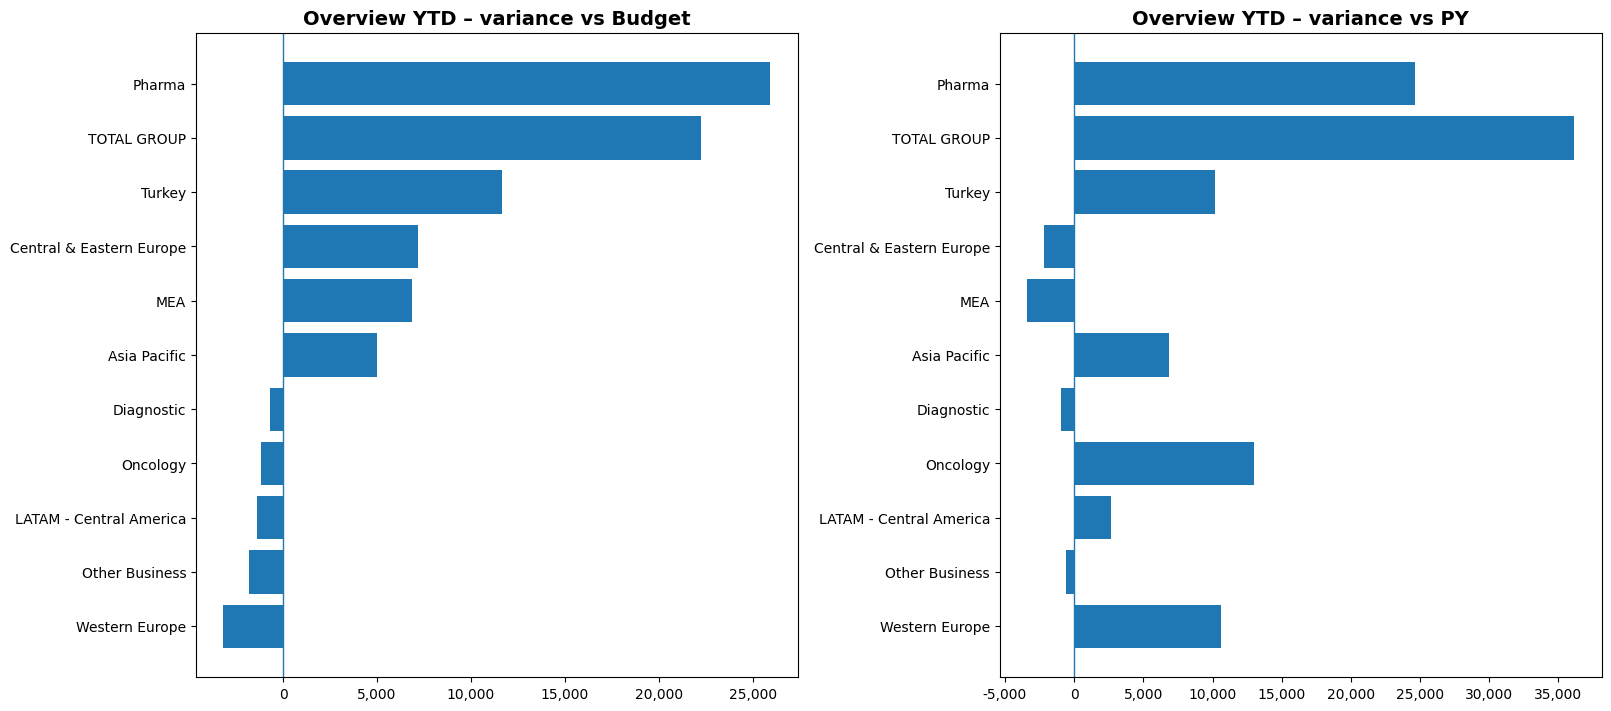

In [22]:

# === 1) OVERVIEW PAGE ===

def build_overview_table(period_scope="YTD", entities=None):
    d = choose_overview_page(period_scope=period_scope).copy()
    if entities is None:
        entities = standard_entities_for_overview()
    d = d[d["entity_label"].isin(entities)].copy()

    cols = [
        "entity_label",
        "variance_vs_budget_abs", "variance_vs_budget_pct",
        "variance_vs_py_abs", "variance_vs_py_pct"
    ]
    table = d[cols].drop_duplicates().copy()
    table = table.rename(columns={
        "entity_label": "Entity",
        "variance_vs_budget_abs": "vs Budget",
        "variance_vs_budget_pct": "vs Budget %",
        "variance_vs_py_abs": "vs PY",
        "variance_vs_py_pct": "vs PY %",
    })
    table["vs Budget"] = table["vs Budget"].map(lambda x: fmt_num(x, 0))
    table["vs Budget %"] = table["vs Budget %"].map(fmt_pct)
    table["vs PY"] = table["vs PY"].map(lambda x: fmt_num(x, 0))
    table["vs PY %"] = table["vs PY %"].map(fmt_pct)
    return table

def plot_overview_variances(period_scope="YTD", entities=None):
    d = choose_overview_page(period_scope=period_scope).copy()
    if entities is None:
        entities = standard_entities_for_overview()
    d = d[d["entity_label"].isin(entities)].copy()
    d = d.sort_values("variance_vs_budget_abs", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

    axes[0].barh(d["entity_label"], d["variance_vs_budget_abs"])
    axes[0].set_title(f"Overview {period_scope} – variance vs Budget")
    axes[0].xaxis.set_major_formatter(FuncFormatter(axis_num_formatter))
    axes[0].axvline(0, linewidth=1)

    axes[1].barh(d["entity_label"], d["variance_vs_py_abs"])
    axes[1].set_title(f"Overview {period_scope} – variance vs PY")
    axes[1].xaxis.set_major_formatter(FuncFormatter(axis_num_formatter))
    axes[1].axvline(0, linewidth=1)

    plt.show()

display(Markdown("## Overview table"))
display(build_overview_table(period_scope="YTD"))

plot_overview_variances(period_scope="YTD")


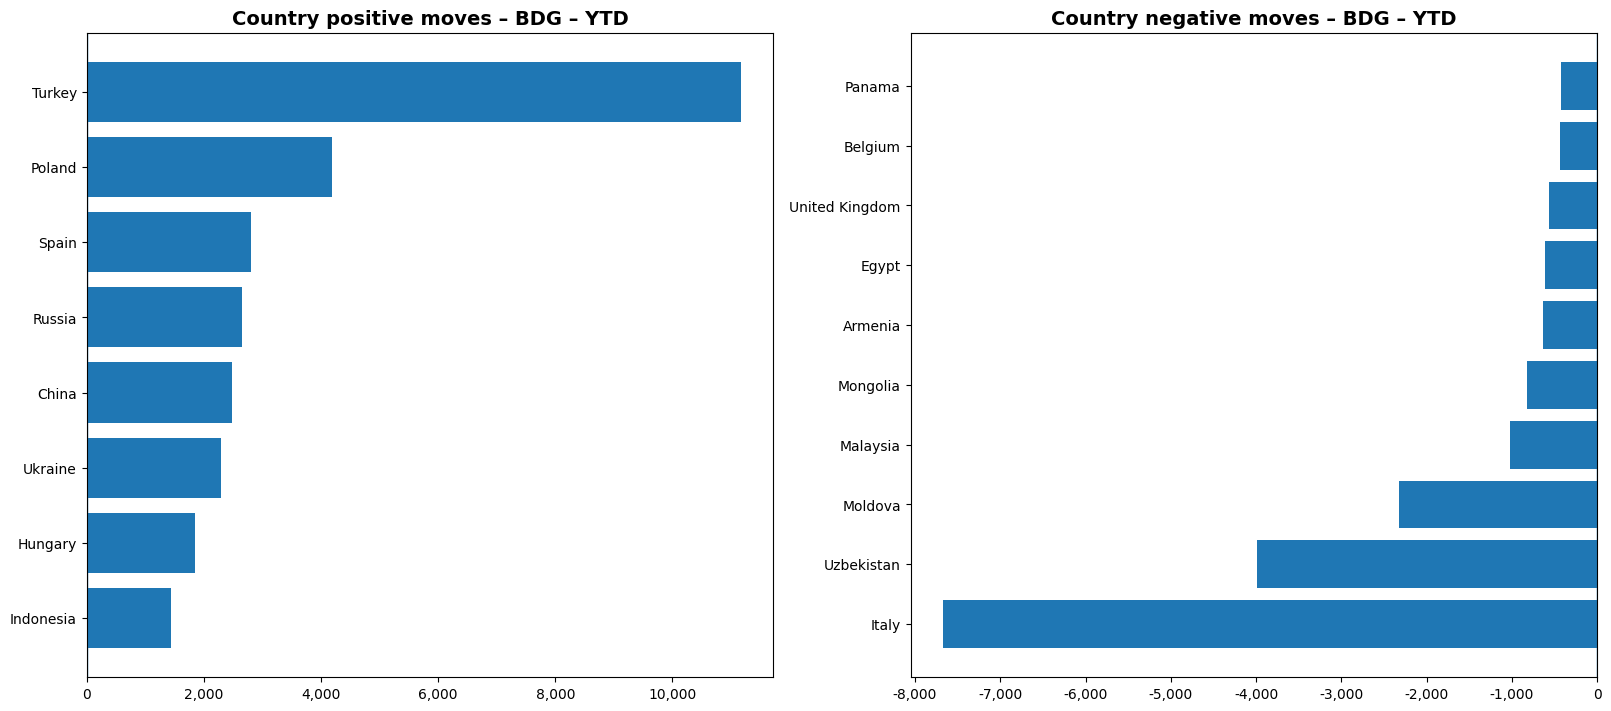

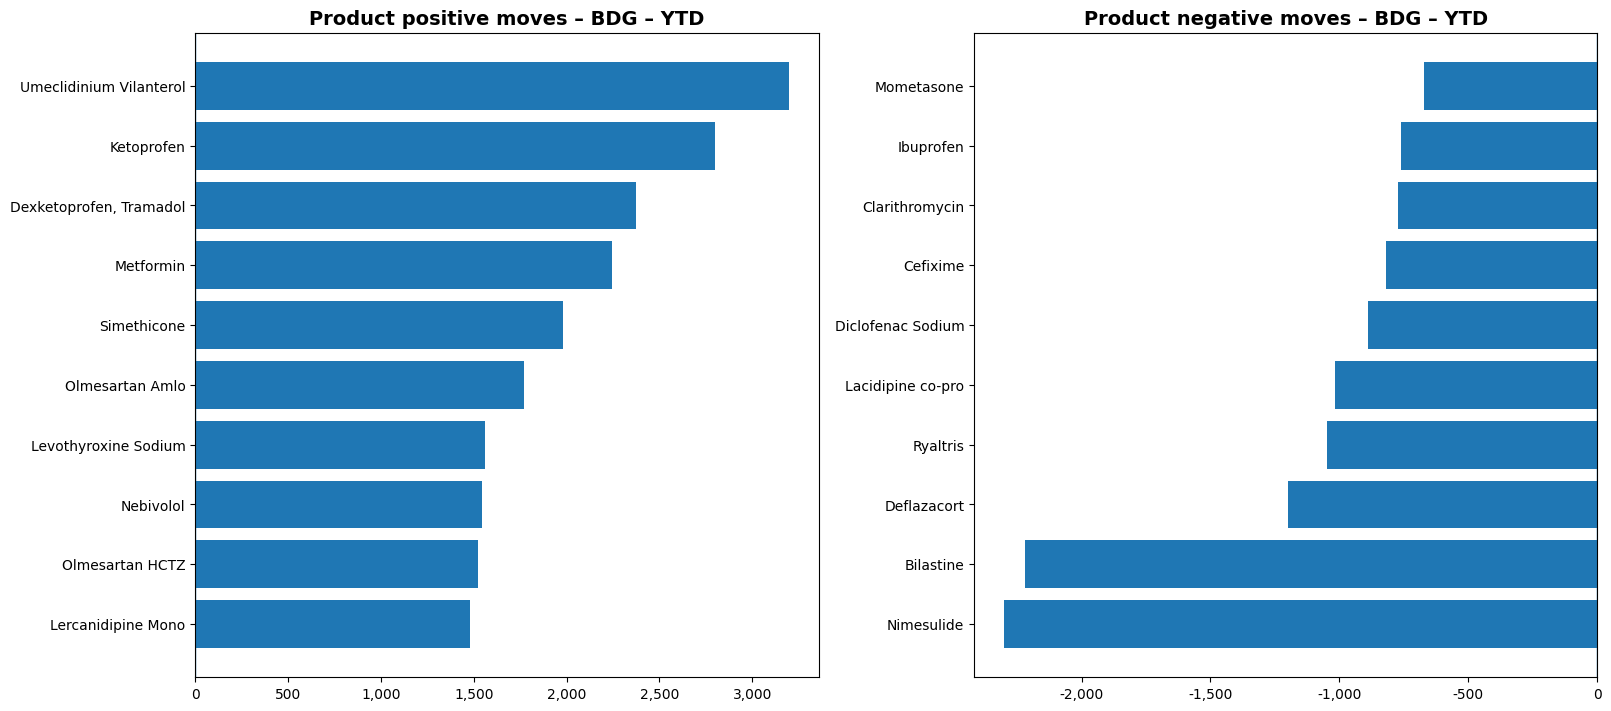

In [23]:

# === 2) COUNTRY / PRODUCT MOVES ===

def plot_moves(entity_type="COUNTRY", comparison_type="BDG", period_scope="YTD", top_n=10):
    d = moves_df.copy()
    d = d[
        (d["entity_type"] == entity_type)
        & (d["comparison_type"] == comparison_type)
        & (d["period_scope"] == period_scope)
    ].copy()
    pos, neg = top_bottom(d, value_col="variance_abs", top_n=top_n)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

    if not pos.empty:
        pos = pos.sort_values("variance_abs", ascending=True)
        axes[0].barh(pos["entity_label"], pos["variance_abs"])
    axes[0].set_title(f"{entity_type.title()} positive moves – {comparison_type} – {period_scope}")
    axes[0].xaxis.set_major_formatter(FuncFormatter(axis_num_formatter))
    axes[0].axvline(0, linewidth=1)

    if not neg.empty:
        neg = neg.sort_values("variance_abs", ascending=True)
        axes[1].barh(neg["entity_label"], neg["variance_abs"])
    axes[1].set_title(f"{entity_type.title()} negative moves – {comparison_type} – {period_scope}")
    axes[1].xaxis.set_major_formatter(FuncFormatter(axis_num_formatter))
    axes[1].axvline(0, linewidth=1)

    plt.show()

plot_moves(entity_type="COUNTRY", comparison_type="BDG", period_scope="YTD", top_n=10)
plot_moves(entity_type="PRODUCT", comparison_type="BDG", period_scope="YTD", top_n=10)


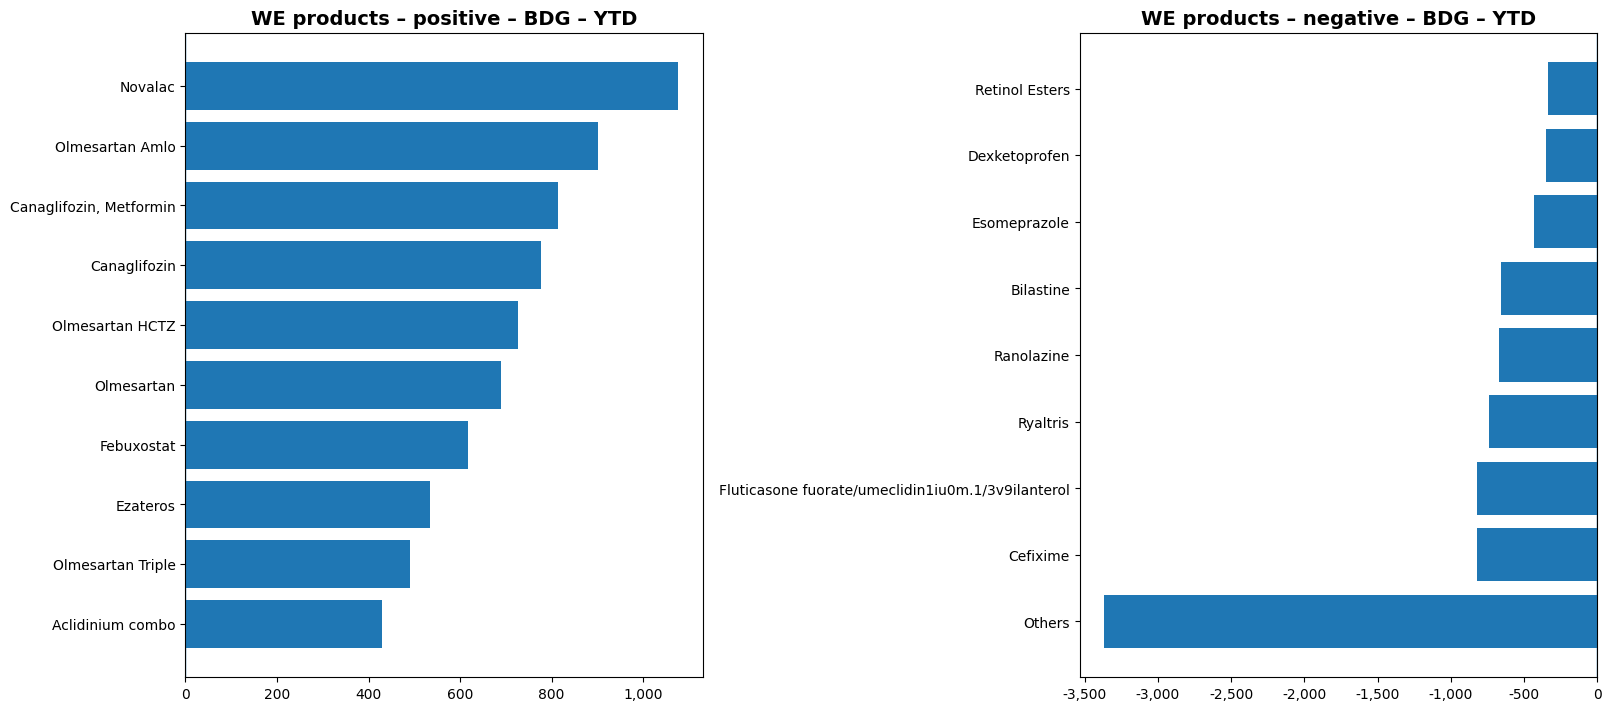

In [24]:

# === 3) AREA PRODUCT PAGE ===

def plot_area_products(cluster="WE", comparison_type="BDG", period_scope="YTD", top_n=10):
    d = choose_area_data(cluster=cluster, comparison_type=comparison_type, period_scope=period_scope).copy()
    # remove generic labels when possible
    generic = {"TOTAL", "Ethic", "OTC", "Aesthetic", "Business", "Country"}
    d = d[~d["entity_label"].isin(generic)].copy()

    pos, neg = top_bottom(d, value_col="variance_abs", top_n=top_n)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

    if not pos.empty:
        pos = pos.sort_values("variance_abs", ascending=True)
        axes[0].barh(pos["entity_label"], pos["variance_abs"])
    axes[0].set_title(f"{cluster} products – positive – {comparison_type} – {period_scope}")
    axes[0].xaxis.set_major_formatter(FuncFormatter(axis_num_formatter))
    axes[0].axvline(0, linewidth=1)

    if not neg.empty:
        neg = neg.sort_values("variance_abs", ascending=True)
        axes[1].barh(neg["entity_label"], neg["variance_abs"])
    axes[1].set_title(f"{cluster} products – negative – {comparison_type} – {period_scope}")
    axes[1].xaxis.set_major_formatter(FuncFormatter(axis_num_formatter))
    axes[1].axvline(0, linewidth=1)

    plt.show()
    return d

_ = plot_area_products(cluster="WE", comparison_type="BDG", period_scope="YTD", top_n=10)


In [25]:

# === 4) OPTIONAL: EXPORT FIGURES ===

EXPORT_DIR = BASE_DIR / "local_report_exports"
EXPORT_DIR.mkdir(exist_ok=True)

def save_current_area_pages(clusters=("WE", "BC_TURKEY", "APAC", "LATAM", "MEA"),
                            comparison_type="BDG", period_scope="YTD", top_n=10):
    for cluster in clusters:
        d = choose_area_data(cluster=cluster, comparison_type=comparison_type, period_scope=period_scope).copy()
        generic = {"TOTAL", "Ethic", "OTC", "Aesthetic", "Business", "Country"}
        d = d[~d["entity_label"].isin(generic)].copy()
        pos, neg = top_bottom(d, value_col="variance_abs", top_n=top_n)

        fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
        if not pos.empty:
            pos = pos.sort_values("variance_abs", ascending=True)
            axes[0].barh(pos["entity_label"], pos["variance_abs"])
        axes[0].set_title(f"{cluster} positive – {comparison_type} – {period_scope}")
        axes[0].axvline(0, linewidth=1)
        axes[0].xaxis.set_major_formatter(FuncFormatter(axis_num_formatter))

        if not neg.empty:
            neg = neg.sort_values("variance_abs", ascending=True)
            axes[1].barh(neg["entity_label"], neg["variance_abs"])
        axes[1].set_title(f"{cluster} negative – {comparison_type} – {period_scope}")
        axes[1].axvline(0, linewidth=1)
        axes[1].xaxis.set_major_formatter(FuncFormatter(axis_num_formatter))

        out = EXPORT_DIR / f"{cluster.lower()}_{comparison_type.lower()}_{period_scope.lower()}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"saved: {out}")

# Esempio:
# save_current_area_pages()



## Come usare questo notebook in locale

1. Metti il notebook nella stessa cartella che contiene:
   - `report_model_output/`
   - oppure `report_model_output_from_final/`

2. Imposta:
```python
SOURCE_KIND = "canonical"
```
oppure
```python
SOURCE_KIND = "final"
```

3. Esegui le celle.  
4. Se vuoi generare immagini PNG per una prova di impaginazione, usa `save_current_area_pages()`.

## Come portarlo poi in Databricks
La logica delle funzioni può essere riusata quasi identica:
- al posto dei CSV locali leggerai le Gold tables
- al posto dei plot matplotlib costruirai i widget della dashboard
- il filtro `SOURCE_KIND` sparirà e verrà sostituito dal catalog/schema
